# [1.3.1] Linear probes ⑥ — 반박 1: 부정문과 극성

**여기서부터 2부다. 입장을 바꾼다.** 1부의 저자는 증거를 쌓았다. 2부의 심사위원은 같은 장부를 열고, 각 주장이 가장 약한 곳을 실험으로 찌른다. 목표는 주장을 무너뜨리는 것이 아니라 **살아남는 범위를 정확히 재는 것**이다.

심사위원의 첫 질문은 ⑤에서 이미 예고했다.

> `The city of Paris is in France.`에서 통한 방향이 `The city of Paris is **not** in France.`에서도 통하는가?

긍정문에서는 "참"과 "도시–국가 짝이 맞음"이 완벽하게 겹친다. 부정문에서는 둘이 **정반대**가 된다(짝은 맞는데 문장은 거짓). 그래서 부정문은 probe가 무엇을 읽는지 가르는 가장 값싼 시험이다.

이 질문에는 역사가 있다. 초기 lie-detector probe들이 부정문에서 실패한다는 지적([Levinstein & Herrmann, *Philosophical Studies* 2024](https://arxiv.org/abs/2307.00175)), "긍정문과 그 부정을 함께 학습하면 일반화가 좋아진다"는 관찰(Marks & Tegmark), 그리고 그 실패를 **2차원 진실 부분공간**으로 설명한 연구([Bürger, Hamprecht & Nadler, NeurIPS 2024](https://arxiv.org/abs/2407.12831))가 있다. 이 notebook은 그 흐름을 우리 모델에서 재현한다.

## 학습 목표, 필수 경로, stop rule

1. cities probe를 부정문에 적용해 **순위가 뒤집히는** 실패를 직접 본다.
2. 그 실패가 층에 따라 어떻게 변하는지 보고, 초반 층의 "진실 probe"가 실제로 무엇을 읽었는지 해석한다.
3. Bürger et al.의 분해 $t_G$(일반 진실 방향) / $t_P$(극성 의존 방향)를 구현하고, leave-one-topic-out으로 검증한다.
4. 고친 방향($t_G$)이 어디까지 일반화되는지, 그리고 2026년 연구들이 그 범위를 어떻게 다시 좁히는지 정리한다.

### ⑦로 넘어가도 되는 기준

- "cities에서 학습한 truth probe가 neg_sp_en_trans에서 AUROC 0.01"이라는 결과를 '실패'가 아니라 '**정보**'로 읽을 수 있다(무엇을 읽었는지 알려 준다).
- 긍정문만으로 학습한 방향이 왜 $t_G$와 $t_P$의 섞임이 되는지 식으로 말할 수 있다.

## 공통 setup

#### Cell 01 · 실행 환경과 공통 import

- **이번 셀의 질문:** 환경이 같은가?
- **출력에서 볼 것:** 버전과 GPU를 확인한다.
- **해석 범위:** 이 notebook은 cache된 activation만 쓴다(없으면 그때 모델을 불러와 계산한다).
- **다음 단계의 목적:** 긍정문·부정문 데이터 6쌍과 cities probe를 준비한다.

In [1]:
# 공통 setup — import는 이 셀 한 곳에서만 한다.
from __future__ import annotations

import gc
import sys
from importlib.metadata import version
from pathlib import Path

HERE = Path.cwd()
if not (HERE / "probe_lab.py").exists():  # 저장소 root 등 다른 위치에서 연 경우
    HERE = next(
        p
        for p in [HERE / "chapter1_transformer_interp/exercises/part31_linear_probes_ko", *HERE.parents]
        if (p / "probe_lab.py").exists()
    )
sys.path.insert(0, str(HERE))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

import probe_lab as pl
import tests

pl.use_style()
np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.precision", 3)
pd.set_option("display.width", 140)

print({
    "torch": torch.__version__,
    "transformers": version("transformers"),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "model": pl.DEFAULT_MODEL,
})

{'torch': '2.11.0+cu128', 'transformers': '5.18.0', 'gpu': 'NVIDIA RTX A6000', 'model': 'meta-llama/Llama-3.1-8B-Instruct'}


#### Cell 02 · 긍정문–부정문 6쌍과 1부의 cities probe

- **이번 셀의 질문:** 부정문 데이터는 어떻게 생겼고, 긍정문과 어떻게 짝지어져 있는가?
- **출력에서 볼 것:** 각 주제의 첫 문장이 긍정문/부정문으로 나란히 출력된다. 부정문의 label은 긍정문의 반대다(`neg_sp_en_trans`처럼 원래 거짓인 번역을 부정하면 참이 된다).
- **해석 범위:** 부정문 파일은 긍정문과 행 단위로 정렬되어 있고, 같은 entity는 같은 group이다. 1부의 cities probe(layer 12, train 도시만으로 학습)를 **다시 학습하지 않고** 그대로 쓴다.
- **다음 단계의 목적:** cities probe를 부정문에 적용한다.

In [2]:
store = pl.ActivationStore()
PROBE_LAYER = pl.load_results("01_observation")["probe_layer"]
TOPICS = ["cities", "sp_en_trans", "inventors", "animal_class", "element_symb", "facts"]
NAMES = [n for t in TOPICS for n in (t, "neg_" + t)]
data = {n: pl.load_dataset(n) for n in NAMES}
for t in TOPICS:
    print(f"{t:>13}: {data[t]['statement'].iloc[0]!r} ({data[t]['label'].iloc[0]})")
    print(f"{'neg_' + t:>13}: {data['neg_' + t]['statement'].iloc[0]!r} ({data['neg_' + t]['label'].iloc[0]})")

cities = data["cities"]
y_c = cities["label"].to_numpy()
split = pl.group_split(cities["group"].to_numpy(), seed=0)
acts12 = {n: store.dataset(n, [PROBE_LAYER])[PROBE_LAYER] for n in NAMES}
mm = pl.fit_mass_mean(acts12["cities"][split.train], y_c[split.train])
lr = pl.fit_logistic(acts12["cities"][split.train], y_c[split.train], C=0.1)

       cities: 'The city of Krasnodar is in Russia.' (1)
   neg_cities: 'The city of Krasnodar is not in Russia.' (0)
  sp_en_trans: "The Spanish word 'con' means 'to speak'." (0)
neg_sp_en_trans: "The Spanish word 'con' does not mean 'to speak'." (1)
    inventors: 'Edwin Herbert Hall lived in the U.S.' (1)
neg_inventors: 'Edwin Herbert Hall did not live in the U.S.' (0)
 animal_class: 'The salmon is a fish.' (1)
neg_animal_class: 'The salmon is not a fish.' (0)
 element_symb: 'Thallium has the symbol Tl.' (1)
neg_element_symb: 'Thallium does not have the symbol Tl.' (0)
        facts: "The Earth's atmosphere protects us from harmful radiation from the sun." (1)
    neg_facts: "The Earth's atmosphere doesn't protect us from harmful radiation from the sun." (0)


# 1️⃣ 심사위원의 첫 시험 — 같은 probe, 부정문

**예측부터.** cities probe가 "참"을 읽는다면 부정문에서도 AUROC가 높아야 한다. "도시–국가 짝이 맞음" 같은 **연관**을 읽는다면 부정문에서 순위가 **뒤집혀야**(AUROC ≪ 0.5) 한다.

#### Cell 03 · cities probe의 부정문 성능 (layer 12)

- **이번 셀의 질문:** 1부의 probe는 부정문에서도 참/거짓의 순위를 맞히는가?
- **출력에서 볼 것:** 저장된 출력(MM/LR): 긍정문 열은 모두 0.94–1.00이다. 부정문 열은 주제마다 다르다. `neg_sp_en_trans` 0.005/0.014, `neg_element_symb` 0.015/0.009는 **순위가 거의 완전히 뒤집혔고**, `neg_inventors` 0.45/0.28, `neg_facts` 0.53/0.48은 우연 근처, `neg_cities` 0.87/0.65, `neg_animal_class` 0.92/0.90은 높다. 빨간 칸이 뒤집힘이다.
- **해석 범위:** AUROC 0.01은 '무작위'가 아니다. **정반대로 정확하다.** probe가 부정문에서도 무언가를 아주 잘 읽고 있는데, 그것이 문장의 참/거짓이 아니라 그 반대와 상관된 무엇이라는 뜻이다. ③의 S5('truth direction generalizes')는 이 표 앞에서 그대로 쓸 수 없다.
- **다음 단계의 목적:** 같은 시험을 층을 따라 반복해 이 뒤집힘이 어디서 오는지 본다.

,MM affirmative,MM negated,LR affirmative,LR negated
topic,,,,
cities,1.000,0.872,1.000,0.652
sp_en_trans,1.000,0.005,1.000,0.014
inventors,0.987,0.453,0.990,0.281
animal_class,1.000,0.923,1.000,0.903
element_symb,1.000,0.015,1.000,0.009
facts,0.944,0.534,0.947,0.481


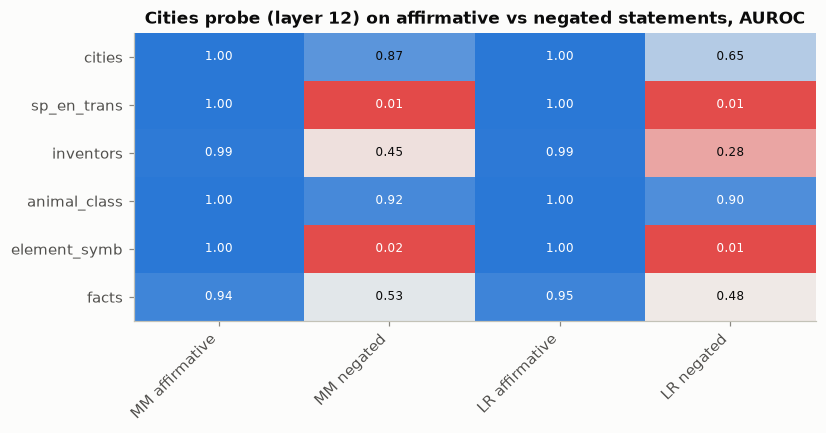

In [3]:
rows = []
for t in TOPICS:
    row = {"topic": t}
    for kind, probe in [("MM", mm), ("LR", lr)]:
        for pol, name in [("affirmative", t), ("negated", "neg_" + t)]:
            row[f"{kind} {pol}"] = pl.auroc(data[name]["label"].to_numpy(), probe.score(acts12[name]))
    rows.append(row)
neg_table = pd.DataFrame(rows).set_index("topic")
display(neg_table)

fig, ax = plt.subplots(figsize=(8, 3.4))
pl.auroc_heatmap(ax, neg_table.to_numpy(), list(neg_table.index), list(neg_table.columns),
                 title=f"Cities probe (layer {PROBE_LAYER}) on affirmative vs negated statements, AUROC")
plt.show()

# 2️⃣ 층을 따라가 보면 — 초반의 "진실 probe"는 무엇을 읽었나

층마다 cities MM probe를 새로 학습하고(train 도시), 부정문 6개에 적용한다.

#### Cell 04 · 층 × 부정문 AUROC 지도 (cities MM probe)

- **이번 셀의 질문:** 부정문에서의 뒤집힘은 모든 층에서 일어나는가?
- **출력에서 볼 것:** 저장된 출력: layer 4–9에서는 여섯 부정문 **모두 0.00–0.36으로 뒤집혀** 있다(`neg_cities` 0.00–0.04, `neg_sp_en_trans`·`neg_element_symb` 0.00–0.23). layer 10–12에서 일부가 돌아오고(`neg_cities` 0.87, `neg_animal_class` 0.92 at layer 12), layer 16 이후 `neg_cities`·`neg_animal_class`·`neg_element_symb`는 0.96 이상, `neg_sp_en_trans`는 0.87–0.95가 된다. `neg_inventors`·`neg_facts`는 끝까지 0.42–0.67에 머문다.
- **해석 범위:** layer 9의 cities probe는 긍정문에서 AUROC 1.000이었는데 `neg_cities`에서는 0.01이다. 즉 그 층의 probe는 **'문장이 참인가'가 아니라 '도시와 국가가 짝이 맞는가'** 를 읽었다고 보는 것이 가장 간단한 설명이다. 부정을 반영한 판단은 더 뒤의 층에서 만들어진다. ①에서 고른 layer 12는 두 신호가 **섞여 있는** 전환 구간에 있다.
- **다음 단계의 목적:** 이 섞임을 두 방향으로 분해한다.

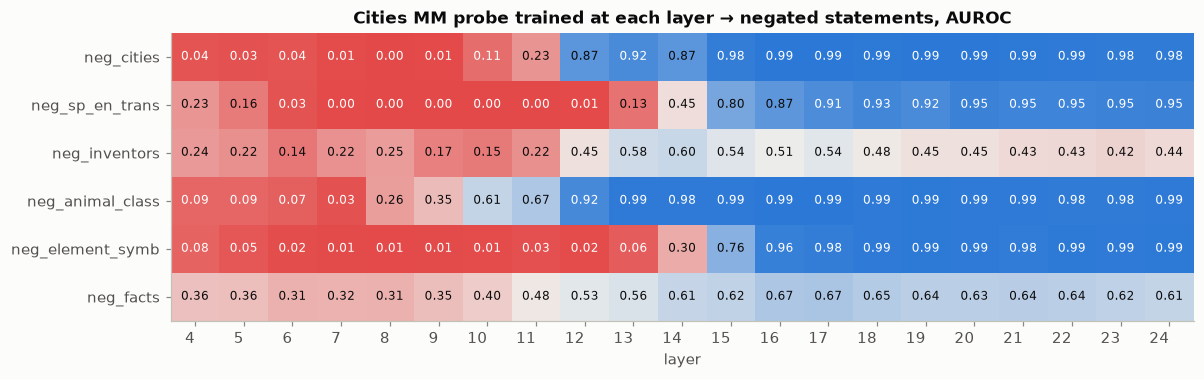

In [4]:
LAYER_GRID = list(range(4, 25))
cities_layers = store.dataset("cities", LAYER_GRID)
neg_layers = {f"neg_{t}": store.dataset(f"neg_{t}", LAYER_GRID) for t in TOPICS}
grid = np.zeros((len(TOPICS), len(LAYER_GRID)))
for j, l in enumerate(LAYER_GRID):
    p = pl.fit_mass_mean(cities_layers[l][split.train], y_c[split.train])
    for i, t in enumerate(TOPICS):
        grid[i, j] = pl.auroc(data[f"neg_{t}"]["label"].to_numpy(), p.score(neg_layers[f"neg_{t}"][l]))

fig, ax = plt.subplots(figsize=(12, 3.4))
pl.auroc_heatmap(ax, grid, [f"neg_{t}" for t in TOPICS], [str(l) for l in LAYER_GRID],
                 title="Cities MM probe trained at each layer → negated statements, AUROC")
ax.set_xlabel("layer")
ax.tick_params(axis="x", rotation=0)
plt.show()

# 3️⃣ 2차원 진실 부분공간 — $t_G$와 $t_P$

Bürger et al.(2024)의 모형은 이렇다. 데이터셋마다 자기 평균을 뺀 activation $\tilde x$에 대해

$$\tilde x \;\approx\; \tau\, t_G \;+\; \tau p\, t_P, \qquad \tau = \pm 1 \text{ (참/거짓)},\quad p = \pm 1 \text{ (긍정/부정)}$$

- $t_G$: **일반 진실 방향**. 긍정문이든 부정문이든 거짓 → 참을 가리킨다.
- $t_P$: **극성 의존 방향**. 긍정문에서는 거짓 → 참, 부정문에서는 **참 → 거짓**을 가리킨다. "도시–국가 짝 맞음" 같은 연관 신호가 여기에 해당한다고 볼 수 있다.

긍정문만으로 probe를 학습하면 $p=+1$뿐이라 $\tau t_G + \tau t_P = \tau(t_G + t_P)$가 되고, probe는 $t_G + t_P$ 섞임을 배운다. 그 방향은 부정문에서 $t_G$ 성분과 $t_P$ 성분이 서로 반대로 작용하므로, 둘 중 어느 쪽이 큰가에 따라 성공하거나 **뒤집힌다**. 위 두 그림이 바로 그것이다.

### ✏️ Exercise 8 · `fit_truth_polarity` 구현

> 난이도 🔴🔴⚪⚪⚪ · 중요도 🔵🔵🔵🔵⚪ · 15분

`X_by_dataset: {name: [N, D]}`, `y_by_dataset: {name: [N]}`를 받는다. 이름이 `neg_`로 시작하면 부정문이다. 각 데이터셋을 자기 평균으로 중심화하고, 계수 행렬 $A = [\tau, \tau p]$ ($[N_{\text{total}}, 2]$)에 대해 $A T \approx \tilde X$를 최소제곱으로 풀어 $T = [t_G; t_P]$ ($[2, D]$)를 돌려준다.

In [5]:
# Scratch
MY_IMPL = False

def my_fit_truth_polarity(X_by_dataset: dict, y_by_dataset: dict) -> tuple[np.ndarray, np.ndarray]:
    raise NotImplementedError

if MY_IMPL:
    tests.test_fit_truth_polarity(my_fit_truth_polarity)

#### Cell 05 · Reference 구현과 leave-one-topic-out 검증 (layer 12)

- **이번 셀의 질문:** 다른 5개 주제(긍정+부정)로 찾은 $t_G$, $t_P$는 처음 보는 주제의 긍정문·부정문에서 어떻게 작동하는가?
- **출력에서 볼 것:** 저장된 출력: $t_G$는 처음 보는 주제의 긍정문 0.96–1.00, **부정문 0.93–1.00**. $t_P$는 긍정문 0.90–1.00, 부정문 **0.00–0.08**(완전히 뒤집힘). 긍정문만 쓴 MM(같은 5개 주제)은 부정문에서 0.02–1.00으로 들쭉날쭉하고, 두 극성을 모두 쓴 MM은 0.93–1.00이다. cos($t_G$, $t_P$) ≈ 0.
- **해석 범위:** $t_P$가 부정문에서 정확히 뒤집히는 것은 모형의 정의상 예상된 결과지만, 그것이 **처음 보는 주제에서도** 일어난다는 것은 경험적 사실이다. 긍정문만으로 학습한 방향은 $t_G$, $t_P$와 각각 cosine 약 0.7이다. 섞임이라는 해석과 맞는다.
- **다음 단계의 목적:** 처음 보는 cities를 $(t_G, t_P)$ 평면에 그려 본다.

In [6]:
def fit_truth_polarity_reference(X_by_dataset, y_by_dataset):
    rows, coef = [], []
    for name, Xd in X_by_dataset.items():
        tau = 2.0 * y_by_dataset[name] - 1.0
        pol = -1.0 if name.startswith("neg_") else 1.0
        rows.append(Xd - Xd.mean(0))                       # 데이터셋별 중심화
        coef.append(np.stack([tau, tau * pol], axis=1))     # [N, 2] = [τ, τp]
    T, *_ = np.linalg.lstsq(np.concatenate(coef), np.concatenate(rows), rcond=None)
    return T[0], T[1]                                        # t_G, t_P


tests.test_fit_truth_polarity(fit_truth_polarity_reference)

ys = {n: data[n]["label"].to_numpy() for n in NAMES}
loto_rows = []
for held in TOPICS:
    train_names = [n for n in NAMES if n.removeprefix("neg_") != held]   # 처음 보는 주제의 긍정·부정문을 모두 뺀다
    tG, tP = pl.fit_truth_polarity({n: acts12[n] for n in train_names}, {n: ys[n] for n in train_names})
    aff = [n for n in train_names if not n.startswith("neg_")]
    mm_aff = pl.fit_mass_mean(np.concatenate([acts12[n] for n in aff]), np.concatenate([ys[n] for n in aff]))
    mm_both = pl.fit_mass_mean(np.concatenate([acts12[n] for n in train_names]), np.concatenate([ys[n] for n in train_names]))
    row = {"held-out topic": held, "cos(tG,tP)": pl.cosine(tG, tP),
           "cos(affMM,tG)": pl.cosine(mm_aff.direction, tG), "cos(affMM,tP)": pl.cosine(mm_aff.direction, tP)}
    for name, pol in [(held, "aff"), ("neg_" + held, "neg")]:
        Xh, yh = acts12[name], ys[name]
        row.update({f"tG {pol}": pl.auroc(yh, Xh @ tG), f"tP {pol}": pl.auroc(yh, Xh @ tP),
                    f"affMM {pol}": pl.auroc(yh, mm_aff.score(Xh)), f"bothMM {pol}": pl.auroc(yh, mm_both.score(Xh))})
    loto_rows.append(row)
loto = pd.DataFrame(loto_rows).set_index("held-out topic")
display(loto[["tG aff", "tG neg", "tP aff", "tP neg", "affMM aff", "affMM neg", "bothMM aff", "bothMM neg"]].round(3))
display(loto[["cos(tG,tP)", "cos(affMM,tG)", "cos(affMM,tP)"]].round(3))

✅ fit_truth_polarity: 합성 데이터의 t_G, t_P 복원 (cos > 0.99)


,tG aff,tG neg,tP aff,tP neg,affMM aff,affMM neg,bothMM aff,bothMM neg
held-out topic,,,,,,,,
cities,1.000,1.000,1.000,0.000,1.000,0.997,1.000,1.000
sp_en_trans,1.000,1.000,1.000,0.000,1.000,0.023,1.000,1.000
inventors,0.976,0.983,0.976,0.033,0.987,0.592,0.976,0.983
animal_class,1.000,1.000,1.000,0.000,1.000,0.985,1.000,1.000
element_symb,1.000,1.000,0.997,0.000,1.000,0.036,1.000,1.000
facts,0.965,0.932,0.895,0.082,0.955,0.583,0.964,0.932


,"cos(tG,tP)","cos(affMM,tG)","cos(affMM,tP)"
held-out topic,,,
cities,0.010,0.720,0.695
sp_en_trans,-0.005,0.740,0.668
inventors,0.003,0.738,0.677
animal_class,-0.028,0.722,0.670
element_symb,-0.032,0.729,0.660
facts,-0.044,0.710,0.671


#### Cell 06 · 처음 보는 cities를 (t_G, t_P) 평면에 투영

- **이번 셀의 질문:** 한 장의 그림에서 '참/거짓'과 '긍정/부정'은 어떻게 배치되는가?
- **출력에서 볼 것:** 가로축($t_G$)에서는 긍정문(●)과 부정문(×) 모두 참(파랑)이 오른쪽이다. 세로축($t_P$)에서는 긍정문의 참은 위, **부정문의 참은 아래**다. 네 덩어리가 X자로 놓인다. 긍정문의 거짓(주황 ●)만 대각선으로 길게 퍼지는데, ①에서 본 '거짓은 넓게 퍼진다'와 같은 현상이다.
- **해석 범위:** $t_G$, $t_P$는 cities를 **전혀 보지 않고** 나머지 5개 주제에서 구했다. 그 평면에서 cities가 이렇게 정렬된다는 것이 '2차원 진실 부분공간'이 주제를 넘어 공유된다는 증거다. 그래도 이것은 하나의 층, 하나의 모델에서의 기하다.
- **다음 단계의 목적:** 고친 방향 $t_G$로 역할극 거짓말을 다시 본다.

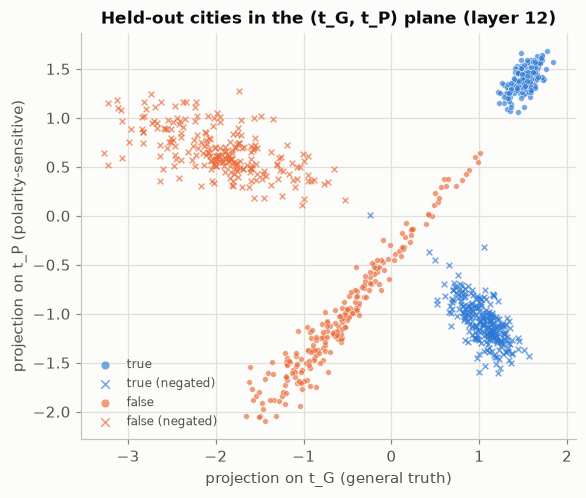

In [7]:
train_names = [n for n in NAMES if n.removeprefix("neg_") != "cities"]
tG_c, tP_c = pl.fit_truth_polarity({n: acts12[n] for n in train_names}, {n: ys[n] for n in train_names})
B = np.stack([tG_c / np.linalg.norm(tG_c), tP_c / np.linalg.norm(tP_c)], axis=1)   # [D, 2]
Xcn = np.concatenate([acts12["cities"], acts12["neg_cities"]])
ycn = np.concatenate([ys["cities"], ys["neg_cities"]])
pol = np.r_[np.ones(len(ys["cities"])), -np.ones(len(ys["neg_cities"]))]
Z = (Xcn - Xcn.mean(0)) @ B
sub = np.random.default_rng(0).choice(len(Z), 900, replace=False)
fig, ax = plt.subplots(figsize=(5.8, 4.8))
pl.scatter_classes(ax, Z[sub], ycn[sub], pol[sub], title="Held-out cities in the (t_G, t_P) plane (layer 12)",
                   xlabel="projection on t_G (general truth)", ylabel="projection on t_P (polarity-sensitive)")
plt.show()

# 4️⃣ 고친 방향은 어디까지 가는가

Marks & Tegmark와 Bürger et al.의 처방은 같다: **두 극성을 모두 넣어 학습하라.** 그러면 $t_P$ 성분이 상쇄되고 $t_G$가 남는다. 여섯 주제 전부(긍정+부정)로 $t_G$를 구해 1부의 가장 극적인 사례였던 역할극 거짓말에 다시 적용한다.

#### Cell 07 · t_G로 역할극 거짓말 다시 보기

- **이번 셀의 질문:** 극성을 보정한 방향은 cities 방향보다 역할극 거짓말을 더 잘, 또는 덜 가르는가?
- **출력에서 볼 것:** 저장된 출력: cities MM 0.976, 여섯 주제 긍정문 MM 0.979, $t_G$ 0.979로 거의 같다. $t_P$만으로도 0.917이 나온다.
- **해석 범위:** 104개 응답, off-policy 데이터 하나에서의 비교라 작은 차이에는 의미를 두지 않는다. 핵심은 극성을 보정해도 이 과제에서 **나빠지지 않는다**는 것이다. $t_P$도 0.92를 내는 것은 이 역할극 거짓말에서는 극성 성분도 거짓과 상관되어 있다는 뜻이다. 거짓말이 부정문 형태로 많이 나오는 데이터였다면 $t_P$를 섞은 방향은 위험했을 것이다.
- **다음 단계의 목적:** 2026년 연구들이 '진실 방향의 일반화'를 어떻게 다시 좁히는지 정리한다.

In [8]:
tG_all, tP_all = pl.fit_truth_polarity({n: acts12[n] for n in NAMES}, ys)
aff_all = pl.fit_mass_mean(np.concatenate([acts12[t] for t in TOPICS]), np.concatenate([ys[t] for t in TOPICS]))
rw = pl.load_dataset("all_unambiguous_replies")
X_rw, y_rw = store.dataset("all_unambiguous_replies", [PROBE_LAYER])[PROBE_LAYER], rw["label"].to_numpy()
rw_table = pd.DataFrame([
    {"direction": "cities MM (Part 1)", "role-play lies AUROC": pl.auroc(y_rw, mm.score(X_rw))},
    {"direction": "6 topics, affirmative-only MM", "role-play lies AUROC": pl.auroc(y_rw, aff_all.score(X_rw))},
    {"direction": "t_G (6 topics, both polarities)", "role-play lies AUROC": pl.auroc(y_rw, X_rw @ tG_all)},
    {"direction": "t_P (polarity-sensitive)", "role-play lies AUROC": pl.auroc(y_rw, X_rw @ tP_all)},
])
display(rw_table.round(3))

,direction,role-play lies AUROC
0,cities MM (Part 1),0.976
1,"6 topics, affirmative-only MM",0.979
2,"t_G (6 topics, both polarities)",0.979
3,t_P (polarity-sensitive),0.917


# 5️⃣ 2024–2026 연구가 다시 좁히는 범위

$t_G$는 1부의 cities 방향보다 분명히 나은 "진실 방향"이다. 그렇다면 이제 "모델은 일반적인 진실 변수를 가진다"고 써도 되는가? 최근 연구들은 각자 다른 축에서 그 범위를 다시 잰다.

| 연구 | 무엇을 바꿔서 시험했나 | 발견 | 이 장의 주장에 주는 의미 |
|---|---|---|---|
| [Orgad et al. 2024 (ICLR 2025)](https://arxiv.org/abs/2410.02707) | 과제(질문응답, 수학 등 10개 데이터) | 진실성 probe는 **과제를 넘어 잘 일반화되지 않는다.** 비슷한 기술을 요구하는 과제끼리만 전이된다("skill-specific"). 모델이 정답을 내부에 가지고도 틀린 답을 생성하는 경우가 있다. | 단순 사실 문장에서의 일반화를 모든 "진실"로 넓히지 않는다. |
| [Liu et al. 2024 (EMNLP)](https://arxiv.org/abs/2407.08582) | 학습 데이터의 다양성(40개 이상 데이터) | 다양한 데이터로 학습하면 교차 과제 일반화가 좋아진다. 양보다 **다양성**이 중요하다. | 극성 보정과 같은 처방의 일반형: 학습 분포가 좁으면 방향도 좁다. |
| [Ying et al. 2026, *Truthfulness Spectrum Hypothesis*](https://arxiv.org/abs/2602.20273) | 진실의 종류(정의적·경험적·논리적·허구적·윤리적), 기만 행동 | 진실 방향은 **영역 일반적인 것부터 영역 특수적인 것까지 스펙트럼**을 이룬다. 대부분 영역 사이에서는 전이되지만 **아첨형 거짓말·기대 반전형 거짓말**에서는 실패하고, 함께 학습하면 회복된다. probe 방향 사이의 (Mahalanobis) cosine이 전이를 거의 완벽히 예측한다(R² = 0.98). | 1부와 ⑥에서 본 "cosine은 낮아도 전이"와 "섞임"을 하나의 틀로 설명한다. |
| [Poulis, Crovella & Terzi 2026 (BlackboxNLP 2026)](https://arxiv.org/abs/2604.03754) | 층, 과제 종류, 난이도, 평가 지시문 | 진실 방향은 사실 과제에서는 앞 층, 추론 과제에서는 뒤 층에 나타나고, 난이도와 prompt의 지시문에 따라 달라진다. | "layer 12의 진실 방향"은 이 데이터·이 형식의 성질이다. |
| [von Klinski et al. 2026 (2026-09)](https://arxiv.org/abs/2609.39807) | 반사실적 페르소나(예: 음모론자) 역할극, 교란 변수와 진실을 반대로 상관시킨 데이터 | 기존 probe 8개 중 다수가 **페르소나의 믿음을 따라간다.** 많은 probe가 진실 대신 학습 데이터에서 진실과 상관되었던 **지시 준수, 응답의 그럴듯함**을 추적한다. | ②에서 "약화됨, 미결"로 남긴 A5(그럴듯함)가 2026년의 실제 실패 모드로 돌아온다. |

**정리:** 부정문은 "어떤 분포 이동을 시험했는가"가 일반화 주장의 범위를 정한다는 것을 보여 준 첫 사례일 뿐이다. 극성을 고치면 다음 축(과제, 진실의 종류, 페르소나, 지시문)에서 같은 질문이 다시 나온다. "universal"은 경계가 계속 움직이는 **경험적 주장**이다.

## 주장 장부 — ⑥의 갱신 (심사위원 판정)

| ID | 1부의 상태 | 주장 | ⑥의 근거 | 판정 |
|---|---|---|---|---|
| C1 | 지지됨 | L12에서 cities 참/거짓이 선형으로 분리된다. | 그대로 성립 | **유지** |
| C3 | 지지됨 (긍정문 한정) | cities 방향은 여러 참/거짓 문장에 공통된 변수를 읽는다. | 부정문에서 6개 주제 중 2개는 거의 완전히 뒤집히고(MM 0.005, 0.015) 2개는 우연 수준(0.45, 0.53). layer 8–11에서는 거의 모두 뒤집힘. | **범위 축소:** cities 방향은 **극성 의존 연관 방향($t_P$)과 일반 진실 방향($t_G$)의 섞임**이다. 긍정문 일반화는 섞임의 두 성분이 같은 쪽을 가리켜서 생긴 것이다. |
| C3′ | (신규) | 두 극성으로 학습한 $t_G$는 처음 보는 주제의 긍정문·부정문 모두에서 참/거짓을 가른다(L12, 0.93–1.00). | ⑥ leave-one-topic-out | **지지됨** (단순 사실 문장, 6개 주제, 한 층) |
| D1 | 관찰됨 | 참/거짓이 최대 분산 축이다. | 긍정문만의 데이터에서 그 축은 $t_G+t_P$ 섞임이다. | **범위 축소:** "참/거짓 축"이 아니라 "긍정문에서 참/거짓과 겹치는 축" |
| C5 | 주장됨 (증거 초과) | 일반적인 진실 변수를 가지고 쓴다. | 2024–26 연구: 과제·진실 종류·페르소나·지시문에 따라 깨짐 | **약화** |

#### Cell 08 · 결과 저장

- **이번 셀의 질문:** ⑧이 모아 읽을 ⑥의 수치를 기록한다.
- **출력에서 볼 것:** `results/06_polarity.json` 경로가 출력된다.
- **해석 범위:** 표와 층 지도를 저장한다.
- **다음 단계의 목적:** ⑦ 반박 2 — 읽힘과 쓰임.

In [9]:
pl.save_results("06_polarity", {
    "probe_layer": PROBE_LAYER,
    "neg_table": neg_table.reset_index().to_dict(orient="records"),
    "layer_grid": {"layers": LAYER_GRID, "datasets": [f"neg_{t}" for t in TOPICS], "auroc": grid},
    "leave_one_topic_out": loto.reset_index().to_dict(orient="records"),
    "roleplay": rw_table.to_dict(orient="records"),
    "claims": [
        {"id": "C1", "status": "유지"},
        {"id": "C3", "status": "범위 축소", "text": "cities 방향은 t_P(극성 의존 연관)와 t_G(일반 진실)의 섞임. 부정문에서 2/6 주제는 순위가 뒤집힘(MM AUROC 0.005, 0.015)."},
        {"id": "C3'", "status": "지지됨", "text": "두 극성으로 학습한 t_G는 처음 보는 주제의 긍정·부정문에서 0.93–1.00 (L12)."},
        {"id": "D1", "status": "범위 축소"},
        {"id": "C5", "status": "약화"},
    ],
})

PosixPath('/workspace/ARENA_3.0/chapter1_transformer_interp/exercises/part31_linear_probes_ko/results/06_polarity.json')